# **Exploratory Data Analysis (EDA)**

In this section, we will perform **Exploratory Data Analysis (EDA)** on the **Customer Churn Dataset** to uncover key patterns and insights that will help in building a better churn prediction model. EDA is a critical step in understanding the data before we start preprocessing and modeling.

### **Goals of EDA**
1. **Understand the structure of the data**: Investigate the dataset to understand the types of variables, their distributions, and how they relate to each other.
2. **Identify missing values and outliers**: Detect any missing data points, outliers, or anomalies that could affect model performance.
3. **Examine distributions**: Visualize the distributions of key variables, such as monthly charges, total charges, and customer churn status.
4. **Correlations and relationships**: Explore how different features (e.g., demographics, contract type, payment method) correlate with churn.
5. **Churn rate analysis**: Analyze churn rates across different customer segments, such as contract types, payment methods, and reasons for churn.

### **Steps in EDA**
1. **Data Summary**:
   - Display basic statistics (mean, median, min, max, etc.).
   - Check data types and identify potential issues.
   
2. **Missing Data Analysis**:
   - Identify missing values and decide on appropriate strategies (e.g., imputation or removal).

3. **Outlier Detection**:
   - Identify outliers using visualizations and statistical methods.

4. **Feature Distributions**:
   - Visualize the distribution of numerical features (e.g., `Monthly Charges`, `Total Charges`).

5. **Categorical Feature Analysis**:
   - Explore categorical features (e.g., `Contract`, `Payment Method`, `Churn Label`).
   - Visualize their distribution and compare them with the target variable (Churn).

6. **Churn Segmentation**:
   - Analyze churn rates across different categories, such as gender, contract type, and churn reason.

By the end of this section, we aim to gather valuable insights that will inform the data preprocessing and feature engineering stages.


# Load Data

In [1]:
# Import Libraries

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load Data

df = pd.read_excel('Telco_customer_churn.xlsx')

### **Step 1: Data Summary**

In this step, we will start by displaying an overview of the dataset. This includes:
1. Checking the first few rows of the dataset to understand its structure.
2. Examining basic statistics for numerical features.
3. Checking the data types of each column to identify any potential issues.

This will give us a sense of the data, what it looks like, and what needs further processing.


In [2]:
# Display the first few rows of the dataset
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
# Display data types and basic statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
# Get basic statistics for numerical columns
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


### **Step 2: Missing Data Analysis**

Next, we'll analyze if there are any missing values in the dataset. Missing data is a common issue that can affect model performance.

We will:
1. Check for missing values in each column.
2. Visualize the missing data pattern.
3. Help to decide whether to impute or drop missing values based on their significance and frequency.

Handling missing data properly is crucial to ensuring the model's accuracy.


In [5]:
# Check for missing values
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

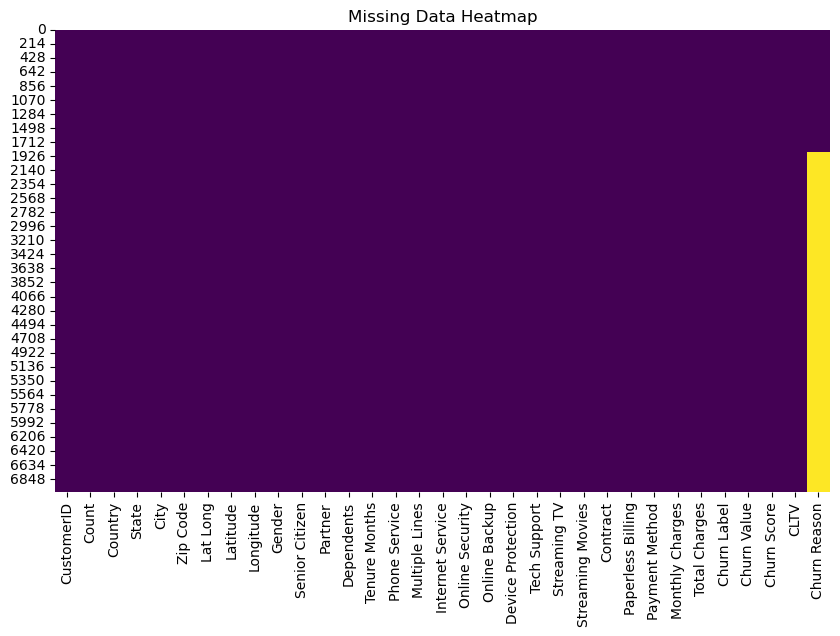

In [6]:
# Check for missing values
df.isnull().sum()

# Visualize missing data
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()


### **Step 3: Outlier Detection**

Outliers are data points that differ significantly from the rest of the data. They can skew the results of many models. In this step, we will:
1. Identify outliers in numerical columns using visualization methods such as boxplots.
2. Help to evaluate whether to remove or treat the outliers based on their impact on the data.

Outlier detection is particularly important when working with numerical data like "Monthly Charges" , "Total Charges and others."


Count - Number of outliers based on quantile method: 0
Zip Code - Number of outliers based on quantile method: 138
Latitude - Number of outliers based on quantile method: 138
Longitude - Number of outliers based on quantile method: 136
Tenure Months - Number of outliers based on quantile method: 11
Monthly Charges - Number of outliers based on quantile method: 136
Churn Value - Number of outliers based on quantile method: 0
Churn Score - Number of outliers based on quantile method: 58
CLTV - Number of outliers based on quantile method: 141


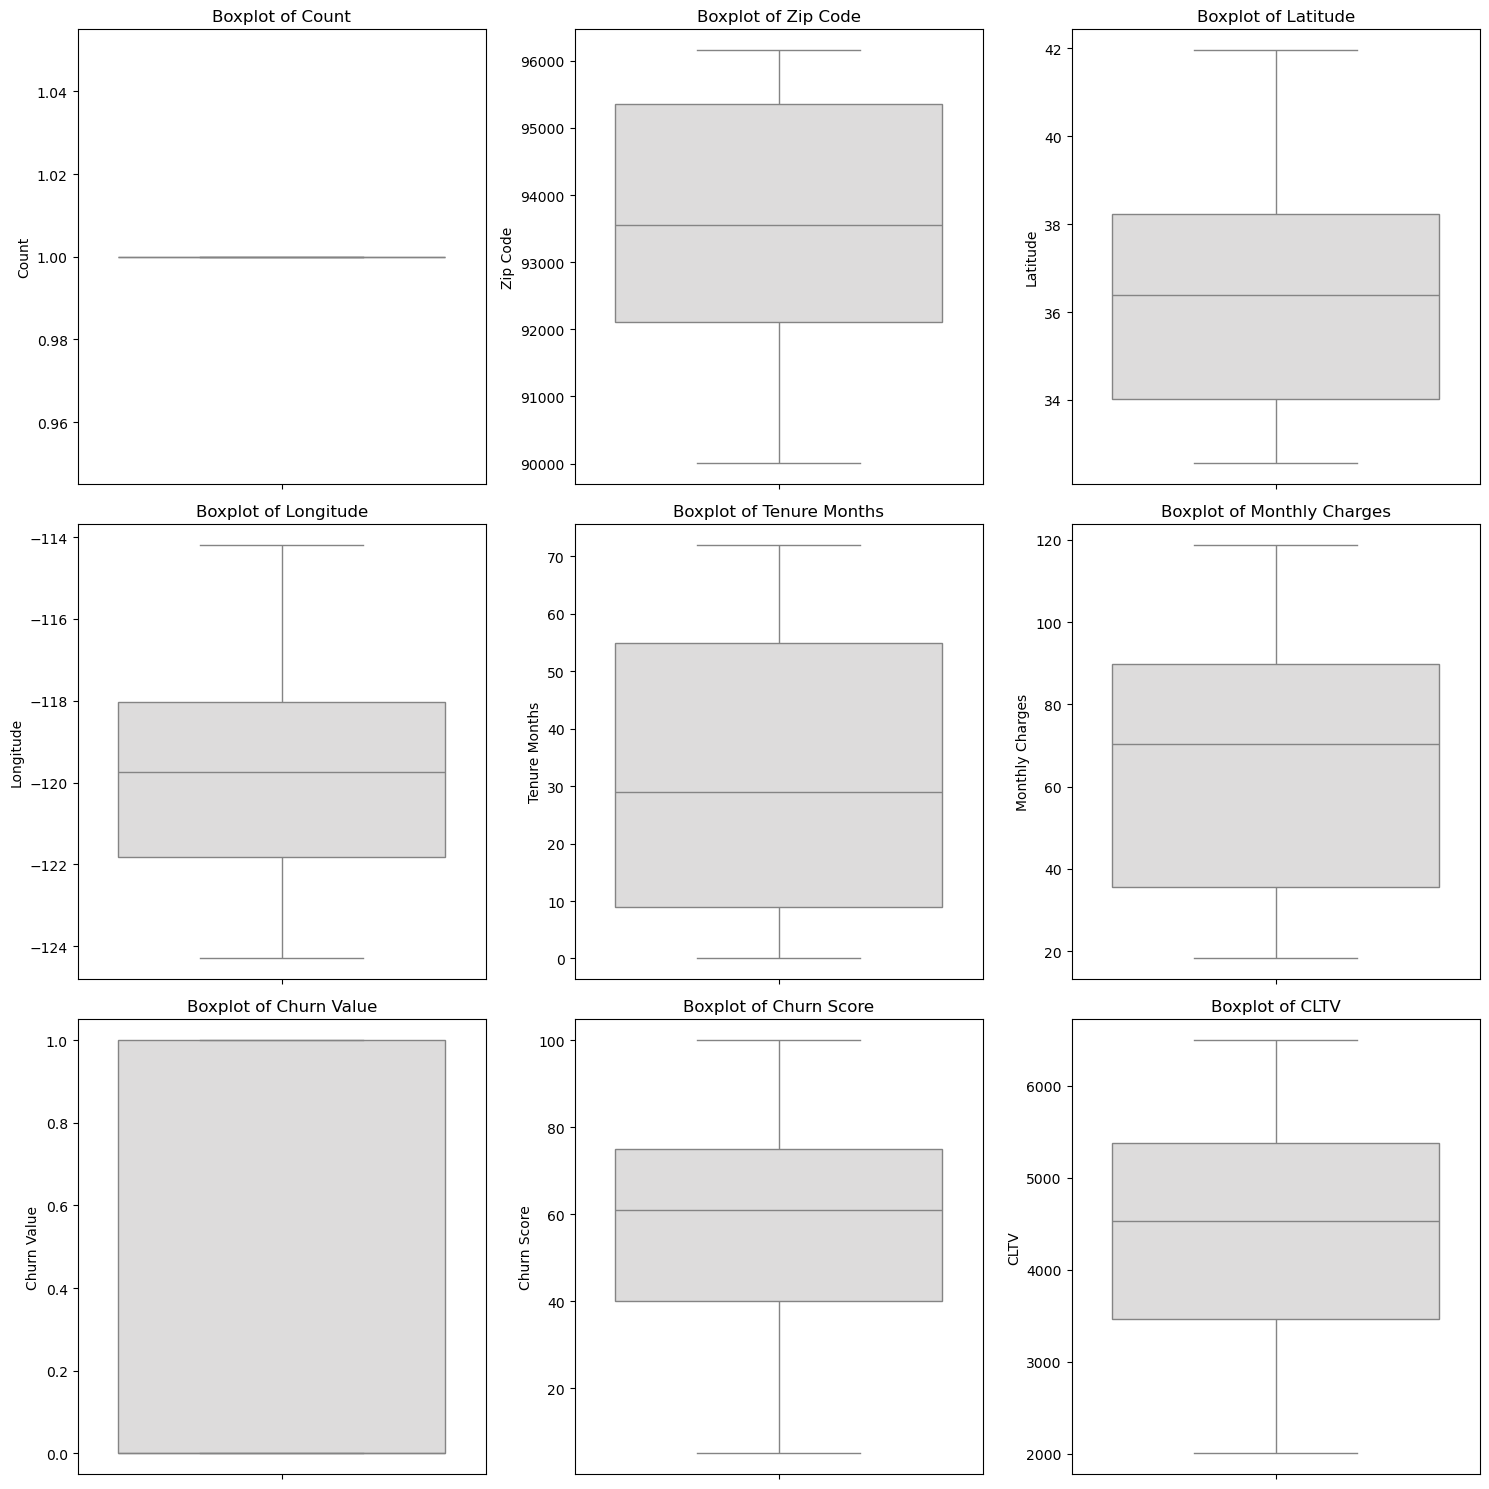

In [11]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Define the number of columns in the grid layout
num_cols = 3  # You can adjust this based on your preferences
num_rows = int(np.ceil(len(numerical_cols) / num_cols))  # Calculate the required number of rows

# Create subplots for boxplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))

# Flatten axes to make indexing easier
axes = axes.flatten()

# Analyze outliers using a quantile-based approach
for idx, col in enumerate(numerical_cols):
    # Apply color grading using different color palettes
    sns.boxplot(data=df, y=col, ax=axes[idx], palette='coolwarm')  # Color palette for boxplots
    axes[idx].set_title(f"Boxplot of {col}")
    axes[idx].set_ylabel(col)
    
    # Outlier detection using custom quantiles (for skewed data)
    lower_quantile = df[col].quantile(0.01)  # 1st percentile
    upper_quantile = df[col].quantile(0.99)  # 99th percentile
    outliers = df[(df[col] < lower_quantile) | (df[col] > upper_quantile)]
    
    # Optionally, display number of outliers
    print(f"{col} - Number of outliers based on quantile method: {outliers.shape[0]}")

# Hide empty subplots (if any)
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### **Analysis of Outliers by Feature**

Based on the boxplots generated above, here's an interpretation of the outliers detected in each numerical feature:

1. **Count**: This column shows no significant outliers. All values are concentrated at 1, indicating each row represents a single customer record.

2. **Zip Code**: The boxplot reveals some outliers at both the lower and upper ends of the range. These represent zip codes that are geographically distant from the central cluster, likely corresponding to customers in remote areas.

3. **Latitude**: Minimal outliers are observed. The data points are tightly distributed within a narrow range, suggesting most customers are concentrated in a specific geographic latitude region.

4. **Longitude**: Similar to Latitude, outliers are minimal. The geographic spread in longitude is relatively constrained, with most customers in a clustered area.

5. **Tenure Months**: A few outliers appear at the upper end, representing long-term customers who have been with the company for an exceptionally long time compared to the majority of the customer base.

6. **Monthly Charges**: Several outliers exist at the upper end of the distribution. These represent customers paying significantly higher monthly fees, likely due to premium service packages or additional add-ons.

7. **Churn Value**: No meaningful outliers are present, as this is a binary variable (0 or 1) representing whether a customer churned or not.

8. **Churn Score**: A few outliers exist at the upper end, representing customers with unusually high churn risk scores despite not all churning in reality.

9. **CLTV (Customer Lifetime Value)**: Outliers appear at the upper end, representing customers with exceptionally high lifetime value to the company, indicating loyal, high-spending customers.

### **Step 4: Feature Distributions**

In this step, we'll analyze the distributions of important numerical features. We will:
1. Visualize the distributions of key columns such as `Monthly Charges`, `Total Charges`, and other important features using histograms.
2. Look for skewness or normality in the distributions.

Visualizing feature distributions helps us understand their nature, which will inform how we preprocess the data.


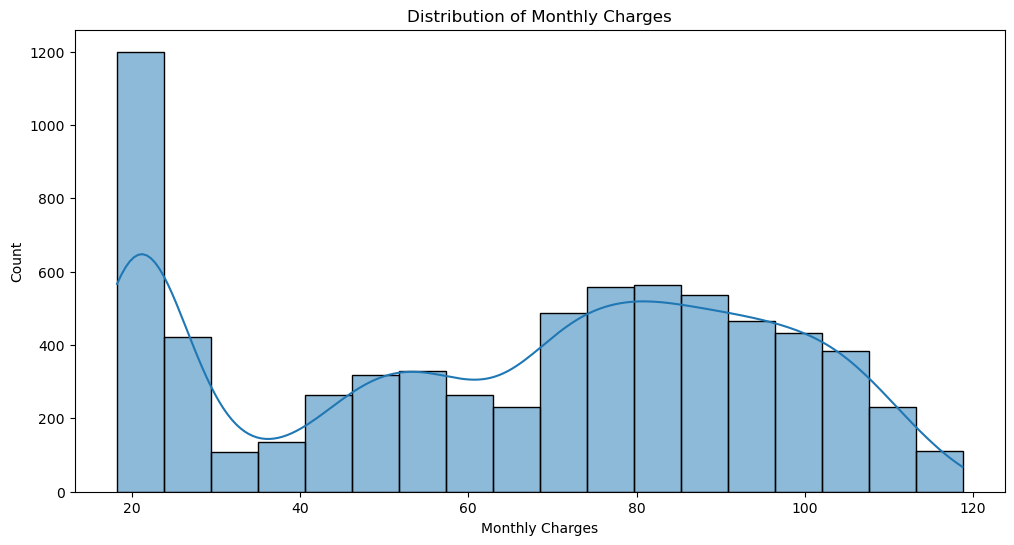

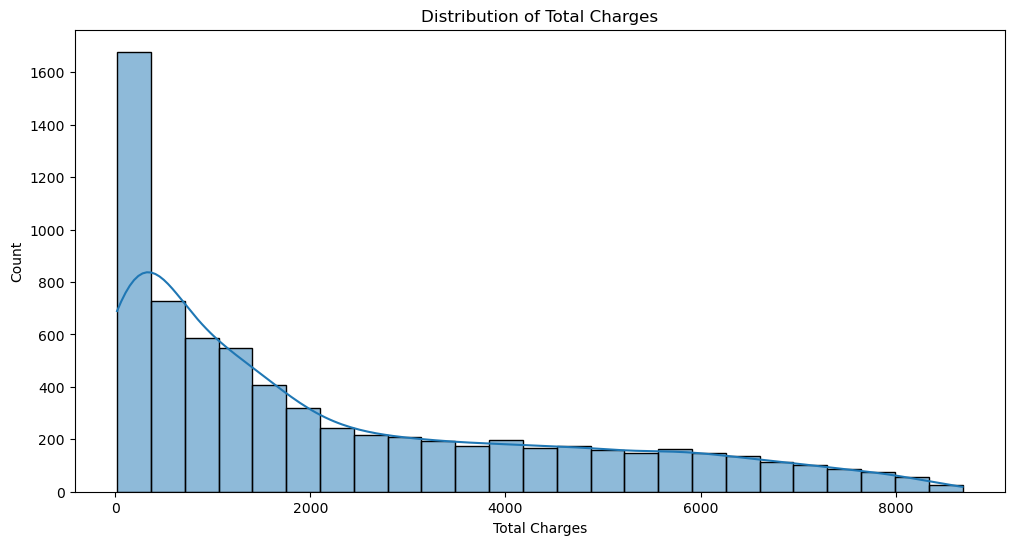

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert empty strings to NaN in 'Total Charges'
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Visualizing the distribution of 'Monthly Charges' using histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['Monthly Charges'], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

# Visualizing the distribution of 'Total Charges' using histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['Total Charges'], kde=True)
plt.title("Distribution of Total Charges")
plt.show()


#### **Monthly Charges Distribution**
- The distribution of **Monthly Charges** shows a **right-skewed** pattern, with a large number of customers having low monthly charges, centered around 20. This suggests that most customers are on lower-tier plans.
- There's a **long tail** extending towards higher charges, indicating a smaller group of customers with premium or higher-cost plans.
- **Outliers** are visible at the higher end, which likely represent customers with significantly higher monthly charges.

#### **Total Charges Distribution**
- The **Total Charges** distribution is also **right-skewed**, with most customers having lower cumulative charges (around 0 to 2000), likely due to shorter tenures or lower monthly payments.
- The **peak near zero** suggests that many customers are relatively new or have lower usage. The tail extending towards 8000 indicates long-term customers or those with high monthly charges.
- The presence of **outliers** at the higher end may indicate high-spending customers who have been subscribed for a long period.


### **Step 5: Categorical Feature Analysis**

Next, we will examine the categorical features in the dataset, such as `Gender`, `Contract`, `Payment Method`, and `Churn Label`. We will:
1. Visualize the distribution of categorical variables.
2. Analyze how these variables correlate with the target variable, `Churn Label`.

This will give us insight into which categories have a higher churn rate and help with feature selection.


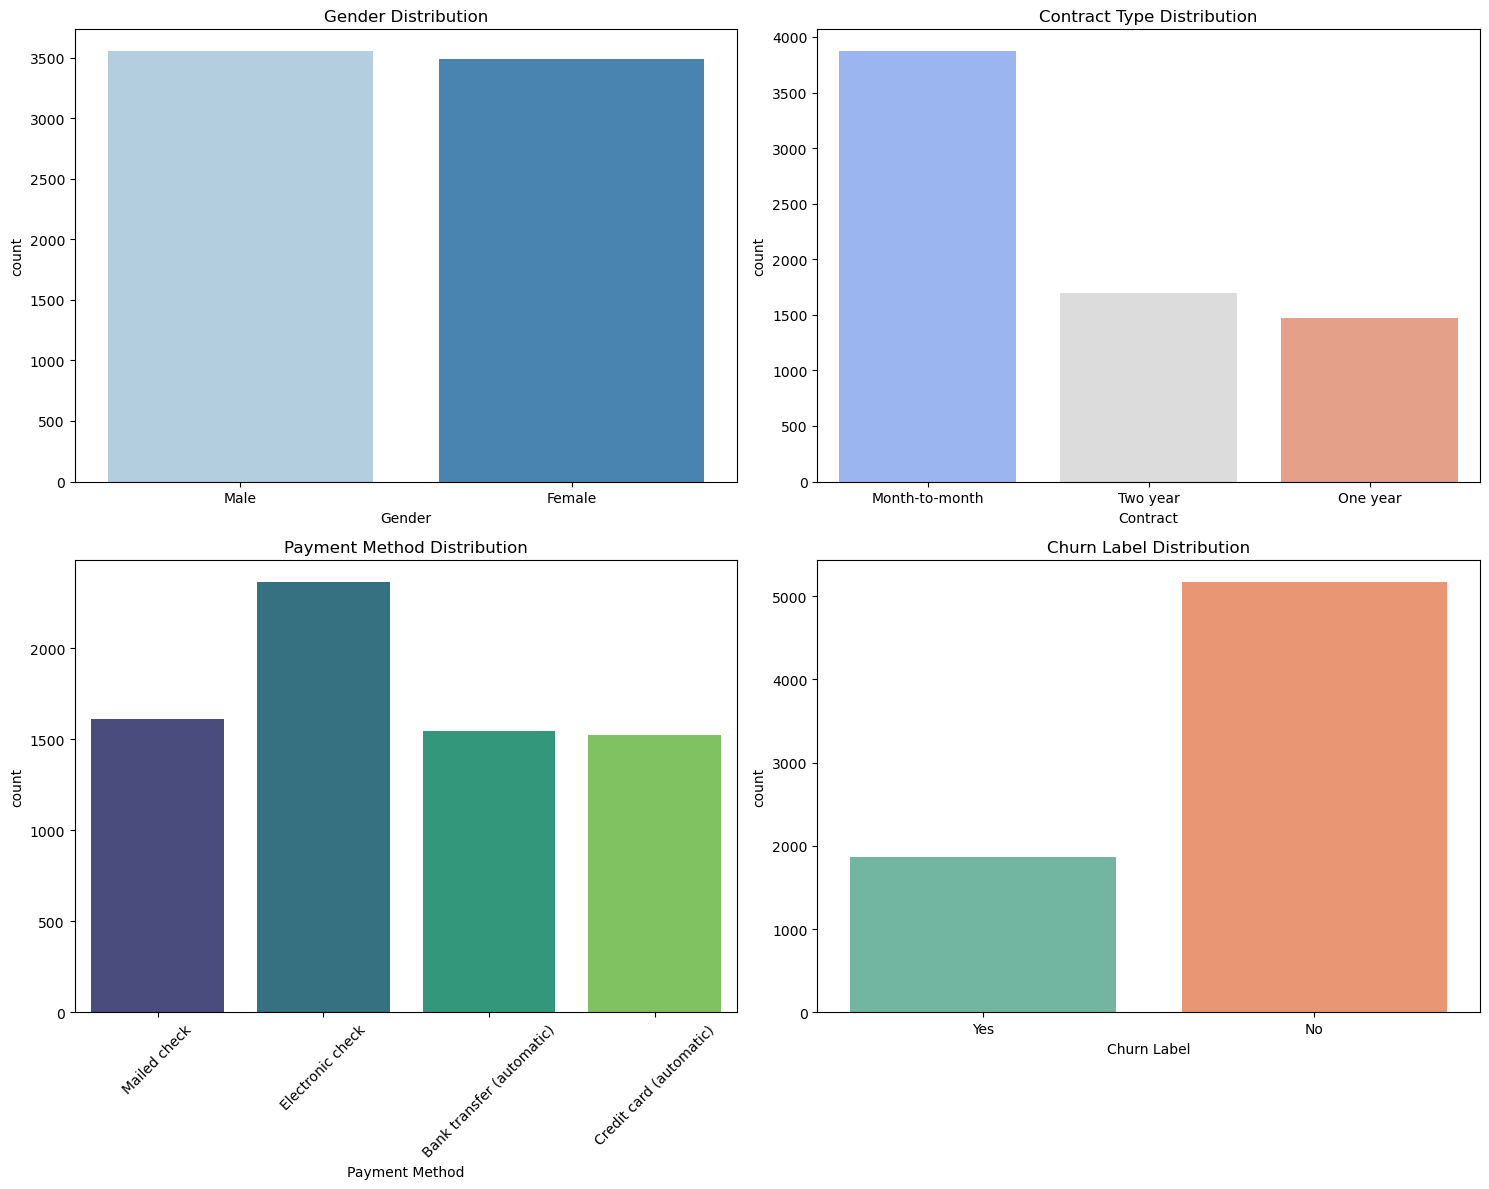

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Visualizing the distribution of categorical features with color grading

# Gender Distribution
sns.countplot(x='Gender', data=df, palette='Blues', ax=axes[0, 0])
axes[0, 0].set_title("Gender Distribution")

# Contract Type Distribution
sns.countplot(x='Contract', data=df, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title("Contract Type Distribution")

# Payment Method Distribution
sns.countplot(x='Payment Method', data=df, palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title("Payment Method Distribution")
axes[1, 0].tick_params(axis='x', rotation=45)

# Churn Label Distribution
sns.countplot(x='Churn Label', data=df, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title("Churn Label Distribution")

# Adjust layout to make sure titles and labels fit
plt.tight_layout()
plt.show()

#### Summary of the Categorical Feature Distributions:

*   **Gender Distribution**:
    
    *   The dataset has a fairly balanced distribution between **Male** and **Female**, with around **3500** entries for each gender.
        
*   **Contract Type Distribution**:
    
    *   The majority of customers have a **Month-to-month contract**, with significantly fewer customers on **One year** or **Two year contracts**. The **Month-to-month** category is the dominant contract type with over **3500** entries.
        
*   **Payment Method Distribution**:
    
    *   The **Electronic check** method is the most common payment method, with over **2000** entries, followed by **Mailed check**. Other methods like **Bank Transfer (automatic)** and **Credit Card (automatic)** have relatively fewer counts.
        
*   **Churn Label Distribution**:
    
    *   The dataset is heavily skewed towards **No churn** (over **5000**), with a small proportion of customers labeled as **Yes churn** (around **2000**).

### **Step 6: Churn Segmentation**

In this step, we will analyze how different customer segments (based on features like `Contract`, `Payment Method`, `Gender`, etc.) are related to churn rates. We will:
1. Compare churn rates across different segments.
2. Visualize the results using suitable plots.

This will help us identify which customer segments are more likely to churn, providing actionable insights for the business.


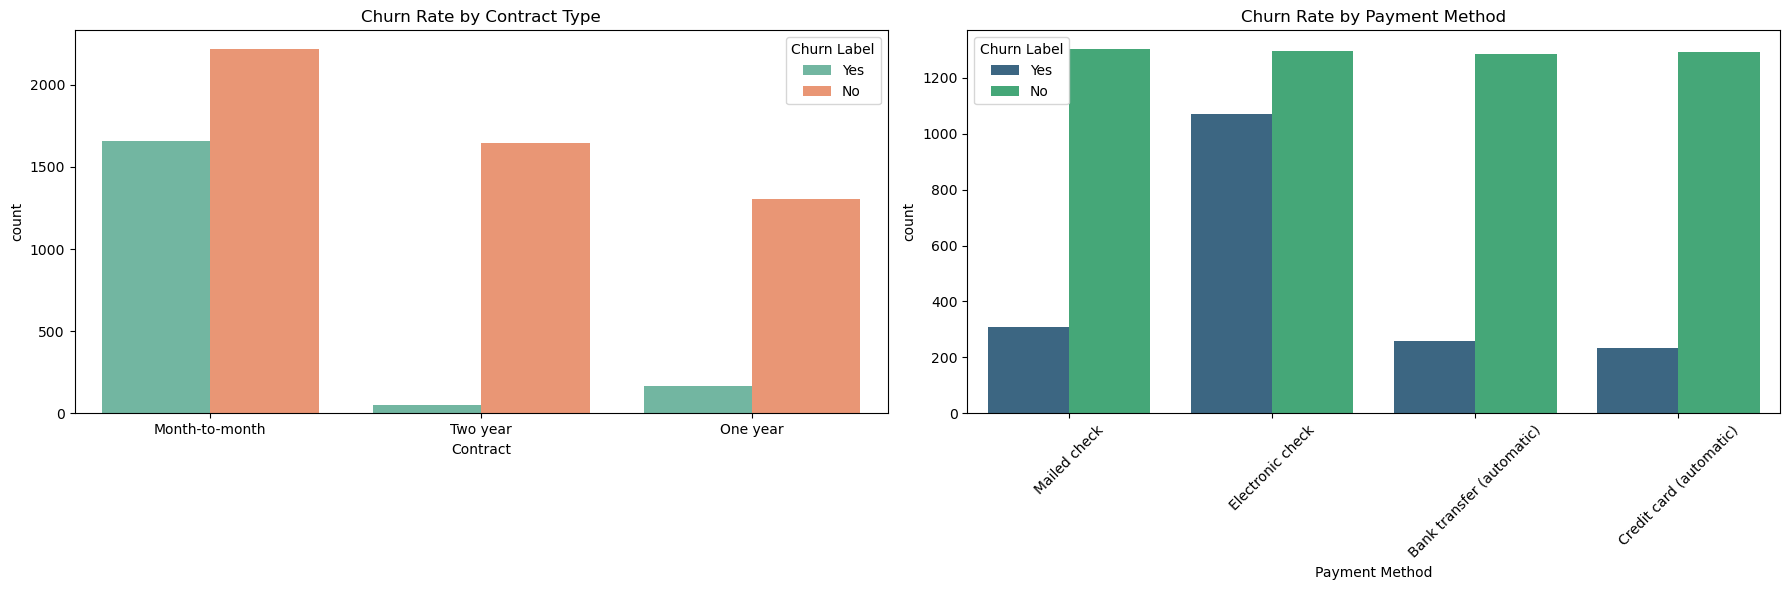

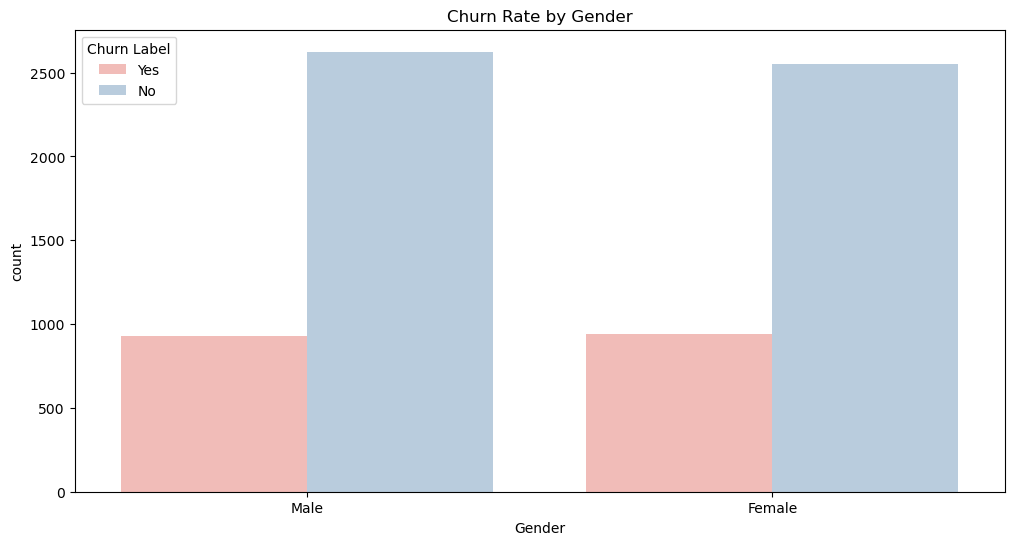

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Churn Rate by Contract Type
sns.countplot(x='Contract', hue='Churn Label', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Churn Rate by Contract Type")

# Churn Rate by Payment Method
sns.countplot(x='Payment Method', hue='Churn Label', data=df, ax=axes[1], palette='viridis')
axes[1].set_title("Churn Rate by Payment Method")
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to make sure titles and labels fit
plt.tight_layout()
plt.show()

# Additional plot for Churn Rate by Gender (Separate Plot)
plt.figure(figsize=(12, 6))
sns.countplot(x='Gender', hue='Churn Label', data=df, palette='Pastel1')
plt.title("Churn Rate by Gender")
plt.show()

### **Step 7: Correlation Matrix**

In this step, we will examine the relationships between numerical features using a **correlation matrix**. A correlation matrix helps us understand how features are related to each other. Strong correlations between features may indicate that one feature could be redundant or unnecessary for model training.

##### **What to Look For:**
- **High Positive or Negative Correlation**: Features with high correlation (close to +1 or -1) are strongly related. These features might provide similar information to the model, and one of them could be removed to avoid multicollinearity.
- **Low Correlation**: Features with a low correlation (close to 0) are independent and carry unique information.

By visualizing the correlation matrix, we can make informed decisions about which features to keep, combine, or remove.


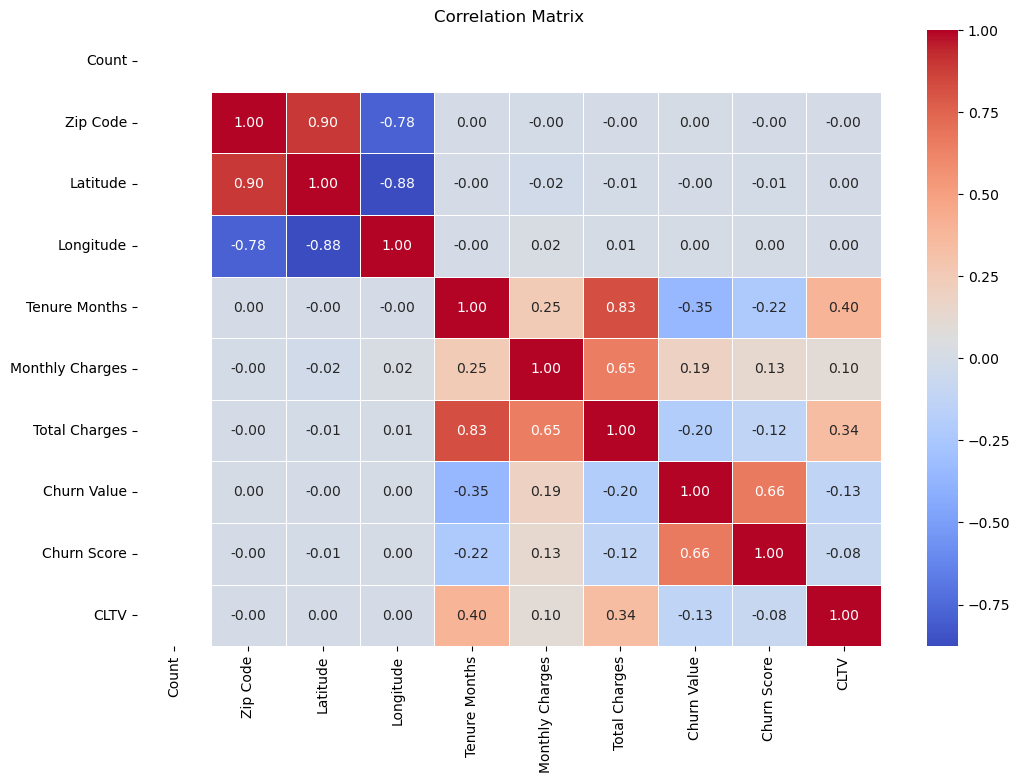

In [17]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Generate the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


The **correlation matrix** visualizes the relationships between numerical features in the dataset. Each cell represents the correlation coefficient between two variables, ranging from **-1** (perfect negative correlation) to **+1** (perfect positive correlation). A value closer to **0** indicates little to no linear relationship.

##### **Key Observations**:
- **Total Charges** and **Tenure Months** have a strong positive correlation (0.83), indicating that longer-tenured customers tend to have higher total charges.
- **Churn Value** and **Churn Score** are positively correlated (0.66), meaning that customers who are more likely to churn have higher churn scores.
- **Latitude** and **Zip Code** also show a strong positive correlation (0.90), likely due to geographic proximity.

This matrix helps identify relationships and redundancies between features, guiding feature selection and model building.

> Now we have done with the exploratory data analysis.
on the next files, we will continue with the data processing.

+ => [Data Processing](https://github.com/MOHSIN184/Telecom_Churn_Prediction/blob/main/4.%20Data_Processing.ipynb)
